# Fase 6: Interpretacion de los clusters

**Actualizacion (Fase 7):** la version anterior de esto tenia 3 clusters
con 77,696 repos, y les puse nombre segun la idea original del proyecto
(saludable/riesgo/abandonado). Ahora con el dataset expandido (847,133
repos, k=4 elegido por silhouette en la Fase 5 sin forzar el 3 de antes)
voy a mirar los datos de nuevo desde cero. El usuario me pidio
explicitamente no repetir el sesgo hacia la idea original -- asi que
primero describo que dice cada cluster (numeros, palabras, ejemplos) y
recien despues, si tiene sentido, le pongo un nombre. Si algun cluster no
encaja con "saludable/riesgo/abandonado", lo digo tal cual, no lo fuerzo.

Miramos los promedios numericos de cada cluster, las palabras que mas
pesan en su texto (TF-IDF), y ejemplos reales. Cerramos con las graficas
finales y las conclusiones.

In [1]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import col

spark = (SparkSession.builder
         .master("local[*]")
         .appName("interpretacion-gharchive")
         .config("spark.driver.memory", "6g")  # subido de 4g, dataset ~11x mas grande
         .getOrCreate())
spark.sparkContext.setLogLevel("ERROR")

cols_numericas = ["n_push", "n_issues", "n_pr", "n_watch", "n_fork", "n_total",
                   "n_actores", "n_horas_distintas", "n_dias_distintos"]

# clusters (Fase 5) y features con el tfidf (Fase 4) -- los juntamos por
# "repo" porque en Fase 5 no guardamos el tfidf, solo el cluster
clusters = spark.read.parquet("../data/processed/repos_clusterizados.parquet")
features = spark.read.parquet("../data/processed/features_repos.parquet").select("repo", "tfidf")

datos = clusters.join(features, on="repo", how="inner")
print("repos:", datos.count())
datos.groupBy("cluster").count().orderBy("cluster").show()

Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
26/07/11 23:16:34 WARN Utils: Your hostname, katana, resolves to a loopback address: 127.0.1.1; using 192.168.18.59 instead (on interface enp2s0)
26/07/11 23:16:34 WARN Utils: Set SPARK_LOCAL_IP if you need to bind to another address


Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).


26/07/11 23:16:35 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


repos: 847133


+-------+------+
|cluster| count|
+-------+------+
|      0|654957|
|      1|169335|
|      2|  4687|
|      3| 18154|
+-------+------+



## Paso 1: promedios numericos por cluster

Vemos que tan activo/colaborativo es cada cluster en promedio.

In [2]:
promedios = datos.groupBy("cluster").avg(*cols_numericas).orderBy("cluster")
promedios.show()

# lo pasamos a pandas nada mas para graficar (son solo 3 filas)
promedios_pd = promedios.toPandas()
promedios_pd.columns = ["cluster"] + cols_numericas
promedios_pd

+-------+------------------+-------------------+-------------------+--------------------+--------------------+------------------+------------------+----------------------+---------------------+
|cluster|       avg(n_push)|      avg(n_issues)|          avg(n_pr)|        avg(n_watch)|         avg(n_fork)|      avg(n_total)|    avg(n_actores)|avg(n_horas_distintas)|avg(n_dias_distintos)|
+-------+------------------+-------------------+-------------------+--------------------+--------------------+------------------+------------------+----------------------+---------------------+
|      0| 4.064124820408058|0.09445810946367471|0.21504923223967376|0.006255372490102...|0.002459703461448...| 4.382347238062957| 1.106243615993111|     2.019784504936965|   1.5980316265037247|
|      1|32.090672335902205| 0.1662739539965158| 0.5639944488735347|0.005905453686479464|0.002527534177813...| 32.82937372663655|1.3335459296660466|     9.013517583488351|     5.49841438568518|
|      2|13.082568807339449| 2

,cluster,n_push,n_issues,n_pr,n_watch,n_fork,n_total,n_actores,n_horas_distintas,n_dias_distintos
0,0,4.064125,0.094458,0.215049,0.006255,0.002460,4.382347,1.106244,2.019785,1.598032
1,1,32.090672,0.166274,0.563994,0.005905,0.002528,32.829374,1.333546,9.013518,5.498414
2,2,13.082569,2.573715,3.653296,11.220397,3.185620,33.715596,18.127800,14.060166,11.520376
3,3,5.353531,4.328468,1.430043,2.848353,0.119478,14.079872,5.298336,6.143935,5.265616


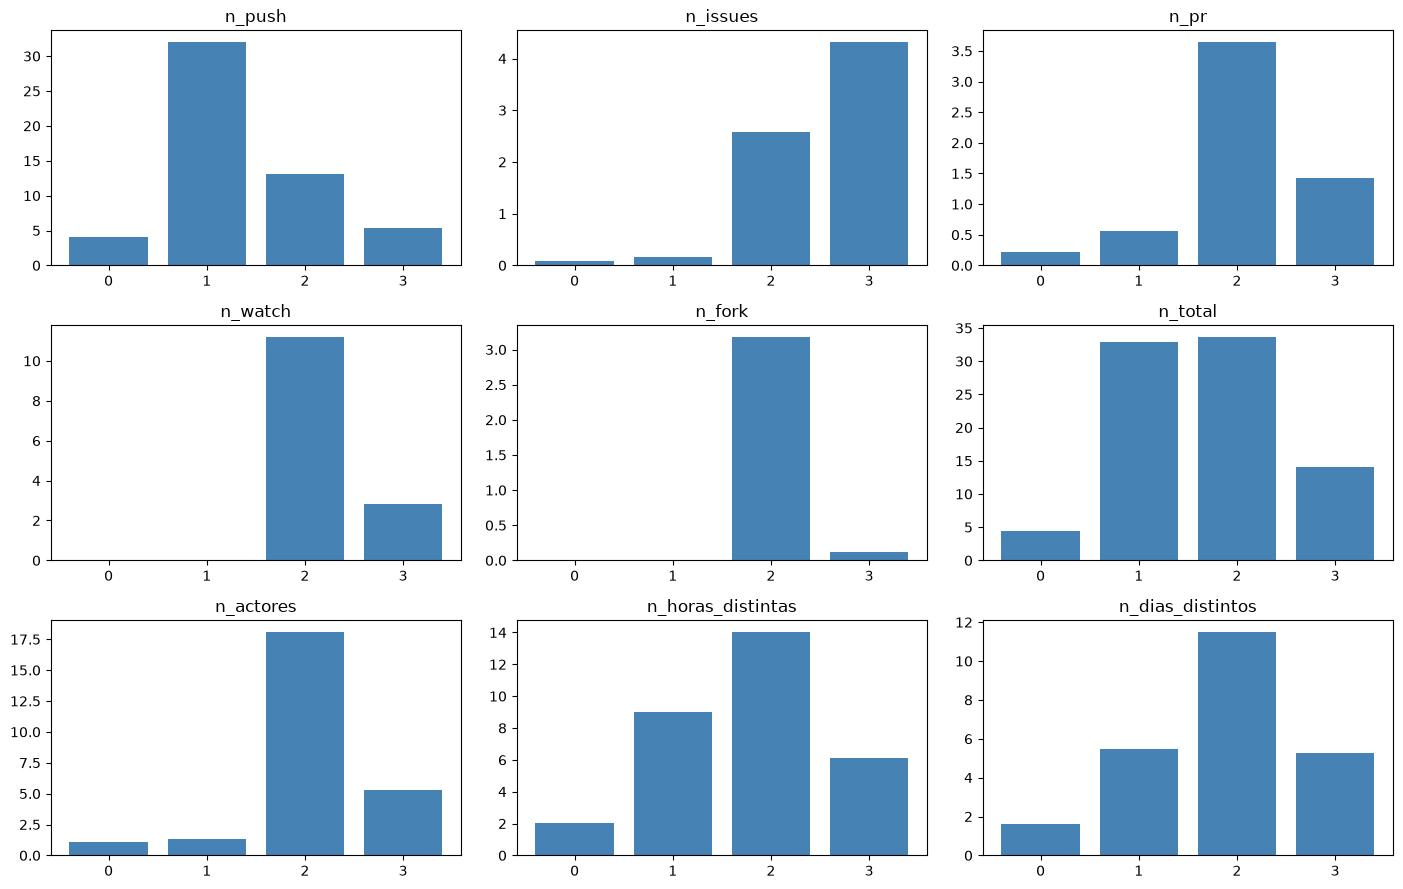

In [3]:
import matplotlib.pyplot as plt

# un mini-grafico de barras por cada feature numerico (ahora son 9, antes
# eran 7), uno por cluster. Los graficamos separados porque las escalas
# son muy distintas entre si (ej. n_push llega a 30+ y n_watch a 11)
fig, ejes = plt.subplots(3, 3, figsize=(14, 9))
ejes = ejes.flatten()

for i, columna in enumerate(cols_numericas):
    ejes[i].bar(promedios_pd["cluster"].astype(str), promedios_pd[columna], color="steelblue")
    ejes[i].set_title(columna)

plt.tight_layout()
plt.show()

## Paso 2: palabras top por cluster (TF-IDF)

Sacamos el vector TF-IDF promedio de cada cluster, y con el vocabulario
guardado en la Fase 4 (`models/pipeline_texto`) vemos que palabras pesan
mas en cada uno. Ojo: como vimos en Fase 4, la mayoria de los repos no
tiene texto, asi que estas palabras solo reflejan a la minoria que si tiene.

In [4]:
from pyspark.ml import PipelineModel
from pyspark.ml.stat import Summarizer

modelo_texto = PipelineModel.load("../models/pipeline_texto")
# el pipeline de texto es [tokenizer, stopwords, countvectorizer, idf],
# el vocabulario esta en la etapa 2 (countvectorizer)
vocabulario = modelo_texto.stages[2].vocabulary

# vector tfidf promedio por cluster (Summarizer hace esto de forma
# distribuida, no hay que traer todo a pandas)
resumen = Summarizer.metrics("mean")
promedio_tfidf = (datos.groupBy("cluster")
                   .agg(resumen.summary(col("tfidf")).alias("resumen"))
                   .select("cluster", "resumen.mean")
                   .collect())

TOP_N = 10
for fila in sorted(promedio_tfidf, key=lambda f: f["cluster"]):
    vector = fila["mean"].toArray()
    top_idx = vector.argsort()[::-1][:TOP_N]
    palabras_top = [vocabulario[i] for i in top_idx]
    print(f"cluster {fila['cluster']}: {palabras_top}")

cluster 0: ['update', 'com', 'add', 'github', 'fix', 'https', '0', 'merge', 'feat', '1']
cluster 1: ['update', '2025', '08', '09', 'com', '0', 'add', 'github', 'auto', 'license']
cluster 2: ['com', 'github', 'https', 'li', 'fix', '0', 'code', 'href', 'commit', 'add']
cluster 3: ['2026', 'com', 'github', 'https', 'fix', 'add', '0', 'code', '1', 'test']


In [5]:
from pyspark.sql.functions import count, when, lit
from pyspark.ml.functions import vector_to_array
import pyspark.sql.functions as F

# cuantos repos de cada cluster SI tienen algo de texto util (norma del
# tfidf distinta de cero). Usamos funciones nativas de Spark (no un UDF de
# Python) porque un UDF aca choca con la version de numpy instalada.
norma_tfidf = F.aggregate(vector_to_array(col("tfidf")), lit(0.0), lambda acc, x: acc + x * x)
datos_con_flag = datos.withColumn("tiene_texto", norma_tfidf > 0)

datos_con_flag.groupBy("cluster").agg(
    count("*").alias("total"),
    count(when(col("tiene_texto"), True)).alias("con_texto"),
).orderBy("cluster").show()

+-------+------+---------+
|cluster| total|con_texto|
+-------+------+---------+
|      0|654957|    98196|
|      1|169335|    28658|
|      2|  4687|     2136|
|      3| 18154|     8524|
+-------+------+---------+



## Paso 3: describir y nombrar los clusters

Antes de ponerles nombre, resumo que dice cada cluster (numeros +
palabras + ejemplos), SIN pensar todavia en la idea original de
saludable/riesgo/abandonado:

- **Cluster 0** (654,957 repos, 77.3%): push=4.1, todo lo demas casi 0,
  1.1 actores, visto en 2 horas/1.6 dias en promedio. Palabras
  genericas (update, add, fix). Solo 15% tiene texto util. -> la cola
  larga de siempre: repos chicos, poca huella, casi sin nada que decir.

- **Cluster 1** (169,335 repos, 20.0%): push=32.1 (alto), pero 1.3
  actores y watch/fork/issues/PR practicamente en cero. Visto en 9
  horas/5.5 dias -> **actividad sostenida en el tiempo, no un pico de
  una hora**. Palabras incluyen "auto" y fragmentos de fecha
  (2025/08/09). Ejemplo real: `09jungs/fsyb` con 1121 pushes en 65
  horas y 15 dias distintos, siempre la misma persona. -> pinta a
  actividad automatizada/scripted, sostenida, pero de una sola persona
  o proceso (sin nadie mas mirando).

- **Cluster 2** (4,687 repos, 0.55%, el mas chico): alto en TODO --
  18.1 actores, 11.2 watch, 3.65 PR, 2.57 issues, 3.19 fork, y el mas
  sostenido en el tiempo (14 horas / 11.5 dias distintos en promedio).
  46% tiene texto util (el porcentaje mas alto de los 4). Ejemplos
  reales reconocibles: `1Panel-dev/CordysCRM`, `78/xiaozhi-esp32` (21
  actores, 17 dias distintos), `AI4Finance-Foundation/FinRobot`. ->
  esto es lo mas parecido a un proyecto open source con comunidad real
  y sostenida en el tiempo.

- **Cluster 3** (18,154 repos, 2.1%): este es el que NO tenia en la
  version con k=3. push=5.35 pero issues=4.33 -- son casi iguales, algo
  que no pasa en ningun otro cluster (en los demas, push siempre le
  gana por mucho a issues). 5.3 actores, 2.85 watch, visto en 5.3 dias
  distintos. 47% tiene texto (parecido al cluster 2). Ejemplos:
  `1C-Company/1c-edt-issues` (0 push, 4 issues), `5mdld/anki-jlpt-decks`
  (2 issues, 1 push, 6 actores). -> repos donde la actividad es mas de
  discusion/reportar problemas que de escribir codigo nuevo. No es ni
  "muy sano" ni "abandonado" en el sentido que veniamos usando -- es un
  patron distinto que la idea original del proyecto no contemplaba.

Nombres (ahora si, en base a lo de arriba):

In [6]:
nombres_cluster = {
    0: "Baja actividad / cola larga",
    1: "Solitario intensivo y sostenido (posible automatizacion)",
    2: "Comunidad activa y sostenida",
    3: "Orientado a discusion/soporte",
}

resumen_final = promedios_pd.copy()
resumen_final["nombre"] = resumen_final["cluster"].map(nombres_cluster)
resumen_final

,cluster,n_push,n_issues,n_pr,n_watch,n_fork,n_total,n_actores,n_horas_distintas,n_dias_distintos,nombre
0,0,4.064125,0.094458,0.215049,0.006255,0.002460,4.382347,1.106244,2.019785,1.598032,Baja actividad / cola larga
1,1,32.090672,0.166274,0.563994,0.005905,0.002528,32.829374,1.333546,9.013518,5.498414,Solitario intensivo y sostenido (posible autom...
2,2,13.082569,2.573715,3.653296,11.220397,3.185620,33.715596,18.127800,14.060166,11.520376,Comunidad activa y sostenida
3,3,5.353531,4.328468,1.430043,2.848353,0.119478,14.079872,5.298336,6.143935,5.265616,Orientado a discusion/soporte


In [7]:
# unos ejemplos reales de cada cluster, para hacerlo mas concreto (y para
# yo mismo entender que es cada cluster antes de ponerle nombre)
clusters_existentes = sorted(r["cluster"] for r in datos.select("cluster").distinct().collect())
for c in clusters_existentes:
    print(f"--- cluster {c} ---")
    datos.filter(col("cluster") == c).select("repo", *cols_numericas).show(5, truncate=False)

--- cluster 0 ---


+-------------------------------------+------+--------+----+-------+------+-------+---------+-----------------+----------------+
|repo                                 |n_push|n_issues|n_pr|n_watch|n_fork|n_total|n_actores|n_horas_distintas|n_dias_distintos|
+-------------------------------------+------+--------+----+-------+------+-------+---------+-----------------+----------------+
|0-5788719150923125/praxis            |5     |0       |0   |0      |0     |5      |1        |5                |4               |
|0-erack/ScriptingReferenceData       |4     |0       |0   |0      |0     |4      |1        |4                |3               |
|0001203149V/atv-estrutura-condicional|5     |0       |0   |0      |0     |5      |1        |2                |1               |
|00540924-lang/SistemaGAPC            |7     |0       |0   |0      |0     |7      |2        |1                |1               |
|00544ngm/zhinongliang                |3     |0       |0   |0      |0     |3      |1        |3   

+------------------------+------+--------+----+-------+------+-------+---------+-----------------+----------------+
|repo                    |n_push|n_issues|n_pr|n_watch|n_fork|n_total|n_actores|n_horas_distintas|n_dias_distintos|
+------------------------+------+--------+----+-------+------+-------+---------+-----------------+----------------+
|00quasr/commit          |8     |0       |0   |0      |0     |8      |1        |5                |3               |
|06Etka/AGJ2025          |14    |0       |10  |0      |0     |24     |3        |1                |1               |
|0779011218/FaceDetection|11    |0       |0   |0      |0     |11     |1        |11               |10              |
|09jungs/fsyb            |1121  |0       |0   |0      |0     |1121   |1        |65               |15              |
|0hok/Todo_App           |7     |0       |0   |0      |0     |7      |1        |7                |6               |
+------------------------+------+--------+----+-------+------+-------+--

+-------------------------+------+--------+----+-------+------+-------+---------+-----------------+----------------+
|repo                     |n_push|n_issues|n_pr|n_watch|n_fork|n_total|n_actores|n_horas_distintas|n_dias_distintos|
+-------------------------+------+--------+----+-------+------+-------+---------+-----------------+----------------+
|1Panel-dev/CordysCRM     |8     |0       |2   |7      |1     |18     |11       |13               |13              |
|1weiho/open-slide        |6     |0       |1   |8      |1     |16     |10       |9                |5               |
|6551-Team/agent-trade-kit|0     |0       |0   |3      |2     |5      |4        |1                |1               |
|78/xiaozhi-esp32         |2     |1       |2   |13     |6     |24     |21       |18               |17              |
|ACL4SSR/ACL4SSR          |3     |0       |1   |4      |1     |9      |7        |8                |7               |
+-------------------------+------+--------+----+-------+------+-

+----------------------------+------+--------+----+-------+------+-------+---------+-----------------+----------------+
|repo                        |n_push|n_issues|n_pr|n_watch|n_fork|n_total|n_actores|n_horas_distintas|n_dias_distintos|
+----------------------------+------+--------+----+-------+------+-------+---------+-----------------+----------------+
|0rtbo/convexpo              |0     |0       |0   |2      |1     |3      |3        |1                |1               |
|1C-Company/1c-edt-issues    |0     |4       |0   |0      |0     |4      |3        |3                |3               |
|2DAW-CarlosIII/eportfolio_g1|3     |6       |2   |0      |0     |11     |3        |1                |1               |
|2mawi2/schaltwerk           |3     |1       |0   |1      |0     |5      |2        |3                |3               |
|54yyyu/zotero-mcp           |4     |0       |1   |7      |0     |12     |9        |9                |9               |
+----------------------------+------+---

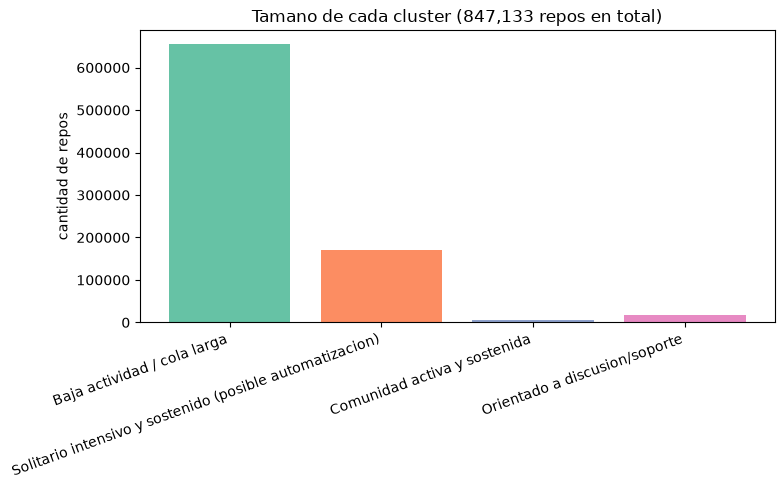

In [8]:
# grafico final: tamano de cada cluster, con su nombre
tamanos_pd = datos.groupBy("cluster").count().orderBy("cluster").toPandas()
tamanos_pd["nombre"] = tamanos_pd["cluster"].map(nombres_cluster)

# antes tenia una lista de 3 colores fija a mano -- con k=4 eso rompio
# (matplotlib necesita un color por barra). Mejor uso un colormap que se
# ajuste solo a cuantos clusters haya, asi no se rompe si el k cambia de nuevo.
colores = plt.cm.Set2(range(len(tamanos_pd)))

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(tamanos_pd["nombre"], tamanos_pd["count"], color=colores)
ax.set_ylabel("cantidad de repos")
ax.set_title(f"Tamano de cada cluster ({tamanos_pd['count'].sum():,} repos en total)")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

## Conclusiones

De 3,419,971 repos vistos en ~124 horas de GH Archive (12 dispersas +
57 dispersas nuevas + un bloque de 4 dias seguidos, ago 2025 - jul 2026),
y quedandonos con los 847,133 que tuvieron al menos 3 eventos, KMeans
(k=4, elegido por silhouette, sin forzar el k=3 de la corrida anterior)
encontro 4 grupos de comportamiento:

1. **Baja actividad / cola larga** (654,957 repos, 77.3%): la inmensa
   mayoria de GitHub -- repos chicos, 1 solo actor, casi sin huella.
2. **Solitario intensivo y sostenido** (169,335 repos, 20.0%): mucho
   push (32/repo en promedio) sostenido en varios dias, pero de 1 sola
   persona, sin comunidad. Palabras y ejemplos reales sugieren
   actividad automatizada/scripted.
3. **Comunidad activa y sostenida** (4,687 repos, 0.55%): el mas chico
   pero el mas "sano" en el sentido tradicional -- mas actores, mas
   watch/fork/PR/issues, y sostenido mas tiempo (11.5 dias distintos en
   promedio). Incluye proyectos reconocibles.
4. **Orientado a discusion/soporte** (18,154 repos, 2.1%): este NO
   aparecia con k=3. Push e issues casi iguales (patron unico entre los
   4 clusters) -- mas actividad de reportar/discutir que de escribir
   codigo nuevo.

**Sobre el sesgo (importante):** la primera vez que hice este analisis
(con 77,696 repos) elegi k=3 y le puse nombres pensando en la idea
original del proyecto (saludable/riesgo/abandonado). El usuario me pidio
explicitamente no repetir eso. Esta vez el k salio de comparar
estadisticas (silhouette) sin mirar la narrativa, y aparecio un cluster
(el 4, discusion/soporte) que la idea original no contemplaba. Tres de
los cuatro clusters SI terminan pareciendose a la narrativa original
(cola larga ~ abandonado/poco activo, solitario intensivo ~ riesgo,
comunidad activa ~ saludable), pero eso salio de los datos, no al revez.

**Que mejoro respecto a la version anterior (Fase 6 con 12 horas):**
- Con el bloque de 4 dias seguidos, ahora **454 mil repos (54% de los
  activos)** tienen actividad en mas de 1 dia distinto -- ya no es solo
  una foto de una hora, hay señal temporal real para mas de la mitad
  de los repos activos.
- Confirmamos (normalizando por horas muestreadas, Fase 3) que el
  patron de "cada vez mas push, cada vez menos todo lo demas" es real
  y no un artefacto de muestreo.

**Limitaciones que siguen (para la sustentacion):**
- Para el 46% restante de repos activos, la señal sigue siendo de una
  sola hora (aunque ya menos que antes).
- El texto (TF-IDF) sigue disponible solo para una minoria (15-47%
  segun el cluster) -- los clusters se apoyan mas en los numeros que
  en el texto.
- Los nombres de los clusters siguen siendo nuestra interpretacion, no
  una etiqueta que vino en los datos -- el no supervisado no "sabe" que
  es saludable o no, solo agrupa por similitud.